In [2]:
from ultralytics import YOLO
import cv2

# ✅ FIX 1: Use forward slash (safer)
model = YOLO("C:/Users/sksaa/OneDrive/Desktop/smartVision AI/notebook/runs/detect/yolo_custom-7/weights/best.pt")

def predict_image(image_path, conf=0.5):

    results = model(image_path, conf=conf)

    result = results[0]
    boxes = result.boxes
    names = model.names

    detections = []

    # ✅ FIX 2: Handle no detections case
    if boxes is None:
        return [], result.plot()

    for box in boxes:
        cls = int(box.cls[0])
        conf_score = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if conf_score >= conf:   # >= better
            detections.append({
                "label": names[cls],
                "confidence": round(conf_score, 2),
                "box": [x1, y1, x2, y2]
            })

    output_img = result.plot()

    return detections, output_img

In [4]:
detections, output_img = predict_image(r"C:\Users\sksaa\OneDrive\Desktop\smartVision AI\smartvision_dataset\detection\images\image_000028.jpg")


image 1/1 C:\Users\sksaa\OneDrive\Desktop\smartVision AI\smartvision_dataset\detection\images\image_000028.jpg: 384x512 6 persons, 98.4ms
Speed: 3.9ms preprocess, 98.4ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 512)



image 1/1 C:\Users\sksaa\OneDrive\Desktop\smartVision AI\smartvision_dataset\detection\images\image_000040.jpg: 416x512 1 bowl, 1 cake, 109.5ms
Speed: 4.0ms preprocess, 109.5ms inference, 5.0ms postprocess per image at shape (1, 3, 416, 512)


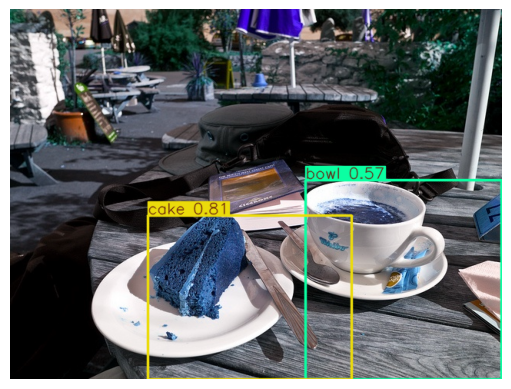

In [6]:
import matplotlib.pyplot as plt

detections, output_img = predict_image(r"C:\Users\sksaa\OneDrive\Desktop\smartVision AI\smartvision_dataset\detection\images\image_000040.jpg")

plt.imshow(output_img)
plt.axis("off")
plt.show()